In [17]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [18]:
# Configuration and paths
min_range = -100
max_range = +0

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",-1
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",-1
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1


In [19]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

all_annotation_list = ['cadd_raw', 'gpn_star_llr_calibrated_mean', 'gpn_score']
existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
group_name = "splicing"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == group_name
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno_wide = (
    anno
    .filter(
        filter_expression
        # (pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .drop_nulls()
)

anno_wide

gpn_score,region,dist_to_tss,gene_name,gene_length,id,Strand,gpn_star_llr_calibrated_mean,cadd_raw,TSS
f32,str,i64,str,i64,str,cat,f64,f32,i64
-5.34,"""ENSG00000081479""",141959,"""LRP2""",235427,"""chr2:169220575:A:G""","""-""",-3.372177,0.900946,169362534
-2.16,"""ENSG00000136531""",170139,"""SCN2A""",197319,"""chr2:165365131:A:G""","""+""",-2.254203,0.476776,165194992
-5.54,"""ENSG00000081479""",205032,"""LRP2""",235427,"""chr2:169157502:T:C""","""-""",-4.281831,2.385964,169362534
-1.8,"""ENSG00000073734""",73185,"""ABCB11""",115828,"""chr2:168958139:G:C""","""-""",-1.00055,-0.242806,169031324
-3.03,"""ENSG00000073734""",17804,"""ABCB11""",115828,"""chr2:169013520:C:T""","""-""",-3.162808,1.800975,169031324
…,…,…,…,…,…,…,…,…,…
-1.51,"""ENSG00000188729""",-1858,"""OSTN""",66376,"""chr3:191197382:A:C""","""+""",0.3842,-0.299584,191199240
1.28,"""ENSG00000162711""",-50936,"""NLRP3""",32954,"""chr1:247365219:C:T""","""+""",0.190362,0.009863,247416155
-7.19,"""ENSG00000155506""",54,"""LARP1""",134621,"""chr5:154683039:T:G""","""+""",-6.034031,4.30672,154682985


In [20]:
# new_anno = pl.scan_parquet("/home/dnanexus/data_dir/abexp1.1_annotations_all_ukb_vars_genebass1e6.parquet")
# new_anno = new_anno.select(['id', 'region', 'abexp_whole_blood']).collect()
# new_anno = new_anno.filter(pl.col('abexp_whole_blood').is_not_null())

# anno_wide = anno_wide.join(new_anno, on=['id', 'region'], how='left').filter(pl.col('abexp_whole_blood').is_not_null())

new_anno = pl.scan_parquet("/home/dnanexus/data_dir/absplice2_all_ukb_vars_genebass1e6.parquet").drop(['Consequence', 'score_category', 'chrom', 'pos', 'ref', 'alt'])

scores2compare = list(set(new_anno.collect_schema().names()) - set(['id', 'region']))

anno_wide = (
    anno_wide.lazy()
    .join(new_anno, on="id", how="inner")
    .drop_nulls()
    .collect(engine='streaming')
)

existing_annos += scores2compare
anno_wide

gpn_score,region,dist_to_tss,gene_name,gene_length,id,Strand,gpn_star_llr_calibrated_mean,cadd_raw,TSS,region_right,pangolin_score,gain_score,loss_score,delta_score,AbSplice_DNA_max,AbSplice2_max,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Brain_Amygdala,Brain_Anterior_cingulate_cortex_BA24,Brain_Caudate_basal_ganglia,Brain_Cerebellar_Hemisphere,Brain_Cerebellum,Brain_Cortex,Brain_Frontal_Cortex_BA9,Brain_Hippocampus,Brain_Hypothalamus,Brain_Nucleus_accumbens_basal_ganglia,Brain_Putamen_basal_ganglia,Brain_Spinal_cord_cervical_c_1,Brain_Substantia_nigra,Breast_Mammary_Tissue,Cells_Cultured_fibroblasts,Cells_EBV_transformed_lymphocytes,Colon_Sigmoid,Colon_Transverse,Esophagus_Gastroesophageal_Junction,Esophagus_Mucosa,Esophagus_Muscularis,Heart_Atrial_Appendage,Heart_Left_Ventricle,Kidney_Cortex,Liver,Lung,Minor_Salivary_Gland,Muscle_Skeletal,Nerve_Tibial,Ovary,Pancreas,Pituitary,Prostate,Skin_Not_Sun_Exposed_Suprapubic,Skin_Sun_Exposed_Lower_leg,Small_Intestine_Terminal_Ileum,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina,Whole_Blood
f32,str,i64,str,i64,str,cat,f64,f32,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.19,"""ENSG00000054267""",75399,"""ARID4B""",196587,"""chr1:235252820:G:T""","""-""",-1.410465,-0.100985,235328219,"""ENSG00000054267""",0.07,0.07,-0.04,0.23,0.013,0.004006,0.001304,0.000902,0.000562,0.000563,0.000638,0.001552,0.000112,0.000108,0.000112,0.001113,0.000638,0.000169,0.000112,0.000169,0.000112,0.000112,0.00011,0.000265,0.000112,0.001228,0.002844,0.004006,0.000595,0.000476,0.000562,0.000398,0.000595,0.000175,0.00011,0.000175,0.000108,0.000638,0.001552,0.000262,0.001228,0.001113,0.000258,0.000476,0.000398,0.000562,0.000595,0.000638,0.000258,0.000398,0.003708,0.001304,0.001304,0.000562,0.00011
-2.55,"""ENSG00000054267""",103430,"""ARID4B""",196587,"""chr1:235224789:C:A""","""-""",-3.377412,1.915019,235328219,"""ENSG00000054267""",0.0,0.0,-0.0,0.0,0.005,0.001243,0.000691,0.000551,0.000417,0.000521,0.000551,0.000762,0.000174,0.000174,0.000174,0.000627,0.000521,0.000267,0.000174,0.000176,0.000176,0.000174,0.000174,0.000417,0.000176,0.000627,0.001028,0.001243,0.000521,0.000417,0.000521,0.000345,0.000459,0.000176,0.000171,0.000176,0.000171,0.000521,0.000691,0.00028,0.000627,0.000594,0.000341,0.000345,0.000345,0.000417,0.000521,0.000521,0.00028,0.000345,0.001033,0.000691,0.000627,0.000459,0.000171
1.96,"""ENSG00000054267""",103523,"""ARID4B""",196587,"""chr1:235224696:T:C""","""-""",-1.701804,0.128016,235328219,"""ENSG00000054267""",0.01,0.01,-0.01,0.0,0.008,0.005575,0.002321,0.001598,0.000841,0.000955,0.00135,0.002992,0.000253,0.000165,0.000253,0.001836,0.00135,0.000261,0.000167,0.000257,0.000253,0.000253,0.000167,0.000841,0.000253,0.001949,0.003094,0.005575,0.000955,0.000841,0.00089,0.000397,0.00089,0.000261,0.000165,0.000253,0.000162,0.001231,0.001949,0.000391,0.001949,0.001836,0.000397,0.000841,0.000713,0.00089,0.000955,0.001231,0.000595,0.000841,0.005342,0.001949,0.001949,0.000841,0.000165
-2.99,"""ENSG00000054267""",75405,"""ARID4B""",196587,"""chr1:235252814:G:A""","""-""",-1.635344,0.815866,235328219,"""ENSG00000054267""",0.0,0.0,-0.0,0.0,0.004,0.000333,0.00021,0.000165,0.000137,0.000137,0.000149,0.000235,0.000052,0.000045,0.000052,0.000182,0.000149,0.00007,0.000052,0.00007,0.000053,0.000052,0.000046,0.000102,0.000053,0.000201,0.000272,0.000333,0.000145,0.000121,0.000137,0.00011,0.000145,0.000071,0.000046,0.000071,0.000045,0.000149,0.000235,0.000091,0.000201,0.000182,0.00009,0.000121,0.00011,0.000137,0.000145,0.000149,0.00009,0.00011,0.000321,0.00021,0.00021,0.000137,0.000046
-4.13,"""ENSG00000054267""",97014,"""ARID4B""",196587,"""chr1:235231205:A:T""","""-""",-1.298717,0.171601,235328219,"""ENSG00000054267""",0.08,0.01,-0.08,0.01,0.003,0.001427,0.00074,0.000467,0.0002

In [21]:
melted_anno = anno_wide.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr1:235252820:G:T""","""ENSG00000054267""","""cadd_raw""",-0.100985
"""chr1:235224789:C:A""","""ENSG00000054267""","""cadd_raw""",1.915019
"""chr1:235224696:T:C""","""ENSG00000054267""","""cadd_raw""",0.128016
"""chr1:235252814:G:A""","""ENSG00000054267""","""cadd_raw""",0.815866
"""chr1:235231205:A:T""","""ENSG00000054267""","""cadd_raw""",0.171601
…,…,…,…
"""chr22:37095546:C:T""","""ENSG00000187045""","""AbSplice_DNA_max""",0.271
"""chr22:37096716:C:A""","""ENSG00000187045""","""AbSplice_DNA_max""",0.336
"""chr22:37084419:C:G""","""ENSG00000187045""","""AbSplice_DNA_max""",0.006


In [22]:
# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .filter(
        (pl.col('n_individuals') <= mac)
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('olink_prot')
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(), 
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr2:68822340:A:G""","""ENSG00000163219_olink""",1,-0.460614,null,"""ENSG00000163219""","""cadd_raw""",0.93911,68679600,"""+""",147234,"""ARHGAP25""",142740
"""chr2:68822340:A:G""","""ENSG00000163219_olink""",1,-0.460614,null,"""ENSG00000163219""","""Brain_Amygdala""",0.000063,68679600,"""+""",147234,"""ARHGAP25""",142740
"""chr2:68822340:A:G""","""ENSG00000163219_olink""",1,-0.460614,null,"""ENSG00000163219""","""Brain_Anterior_cingulate_corte…",0.000065,68679600,"""+""",147234,"""ARHGAP25""",142740
"""chr2:68822340:A:G""","""ENSG00000163219_olink""",1,-0.460614,null,"""ENSG00000163219""","""delta_score""",0.0,68679600,"""+""",147234,"""ARHGAP25""",142740
"""chr2:68822340:A:G""","""ENSG00000163219_olink""",1,-0.460614,null,"""ENSG00000163219""","""gpn_star_llr_calibrated_mean""",-1.893829,68679600,"""+""",147234,"""ARHGAP25""",142740
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr9:116187150:A:T""","""ENSG00000182752_olink""",1,-0.666316,null,"""ENSG00000182752""","""Brain_Substantia_nigra""",0.000033,116153790,"""+""",248532,"""PAPPA""",33360
"""chr9:116187150:A:T""","""ENSG00000182752_olink""",1,-0.666316,null,"""ENSG00000182752""","""Kidney_Cortex""",0.000039,116153790,"""+""",248532,"""PAPPA""",33360
"""chr9:116187150:A:T""","""ENSG00000182752_olink""",1,-0.666316,null,"""ENSG00000182752""","""Nerve_Tibial""",0.000037,116153790,"""+""",248532,"""PAPPA""",33360


In [23]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",9630
"""Brain_Amygdala""",9630
"""Brain_Anterior_cingulate_corte…",9630
"""delta_score""",9630
"""gpn_star_llr_calibrated_mean""",9630
…,…
"""Esophagus_Gastroesophageal_Jun…",9630
"""Artery_Coronary""",9630
"""Colon_Sigmoid""",9630


In [37]:
pos_anno = ['loss_score', 'gpn_star_llr_calibrated_mean', 'gpn_score']

corr_df = (
    pg_df
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "gene_name", "olink_prot", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_olink_value', 'annotation_score']
    )
    .group_by(["region", "gene_name", "olink_prot", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_olink_value_rank", propagate_nans=True)
    )
    # .join(
    #     anno_config_df, on='annotation'
    # )
    .with_columns(
        # corr_beta = pl.col('correlation')*pl.col('annotation_dir')
        corr_beta = pl.when(~pl.col('annotation').is_in(pos_anno)).then(pl.col('correlation') * -1).otherwise(pl.col('correlation'))
    )
)

filt_corr_df = corr_df
# filt_corr_df = corr_df.filter(~pl.col('category').is_in(['missense', 'plof', 'naive', 'splicing']))

consistent_genes = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    # .filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
)

filt_corr_df = filt_corr_df.join(consistent_genes, on=['region', 'gene_name'], how='inner')
filt_corr_df = filt_corr_df.filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
filt_corr_df

region,gene_name,olink_prot,annotation,n_variants,correlation,corr_beta,n_annotations
str,str,str,str,u64,f64,f64,u64
"""ENSG00000115607""","""IL18RAP""","""ENSG00000115607_olink""","""Brain_Cerebellar_Hemisphere""",18,-0.128503,0.128503,58
"""ENSG00000085514""","""PILRA""","""ENSG00000085514_olink""","""Pancreas""",15,-0.49866,0.49866,58
"""ENSG00000117298""","""ECE1""","""ENSG00000117298_olink""","""Small_Intestine_Terminal_Ileum""",29,0.128587,-0.128587,58
"""ENSG00000153048""","""CARHSP1""","""ENSG00000153048_olink""","""Liver""",18,-0.099225,0.099225,58
"""ENSG00000161944""","""ASGR2""","""ENSG00000161944_olink""","""Testis""",20,-0.131272,0.131272,58
…,…,…,…,…,…,…,…
"""ENSG00000069702""","""TGFBR3""","""ENSG00000069702_olink""","""delta_score""",21,-0.436774,0.436774,58
"""ENSG00000240505""","""TNFRSF13B""","""ENSG00000240505_olink""","""Minor_Salivary_Gland""",9,-0.4,0.4,58
"""ENSG00000173546""","""CSPG4""","""ENSG00000173546_olink""","""Adipose_Visceral_Omentum""",23,-0.090437,0.090437,58


In [38]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


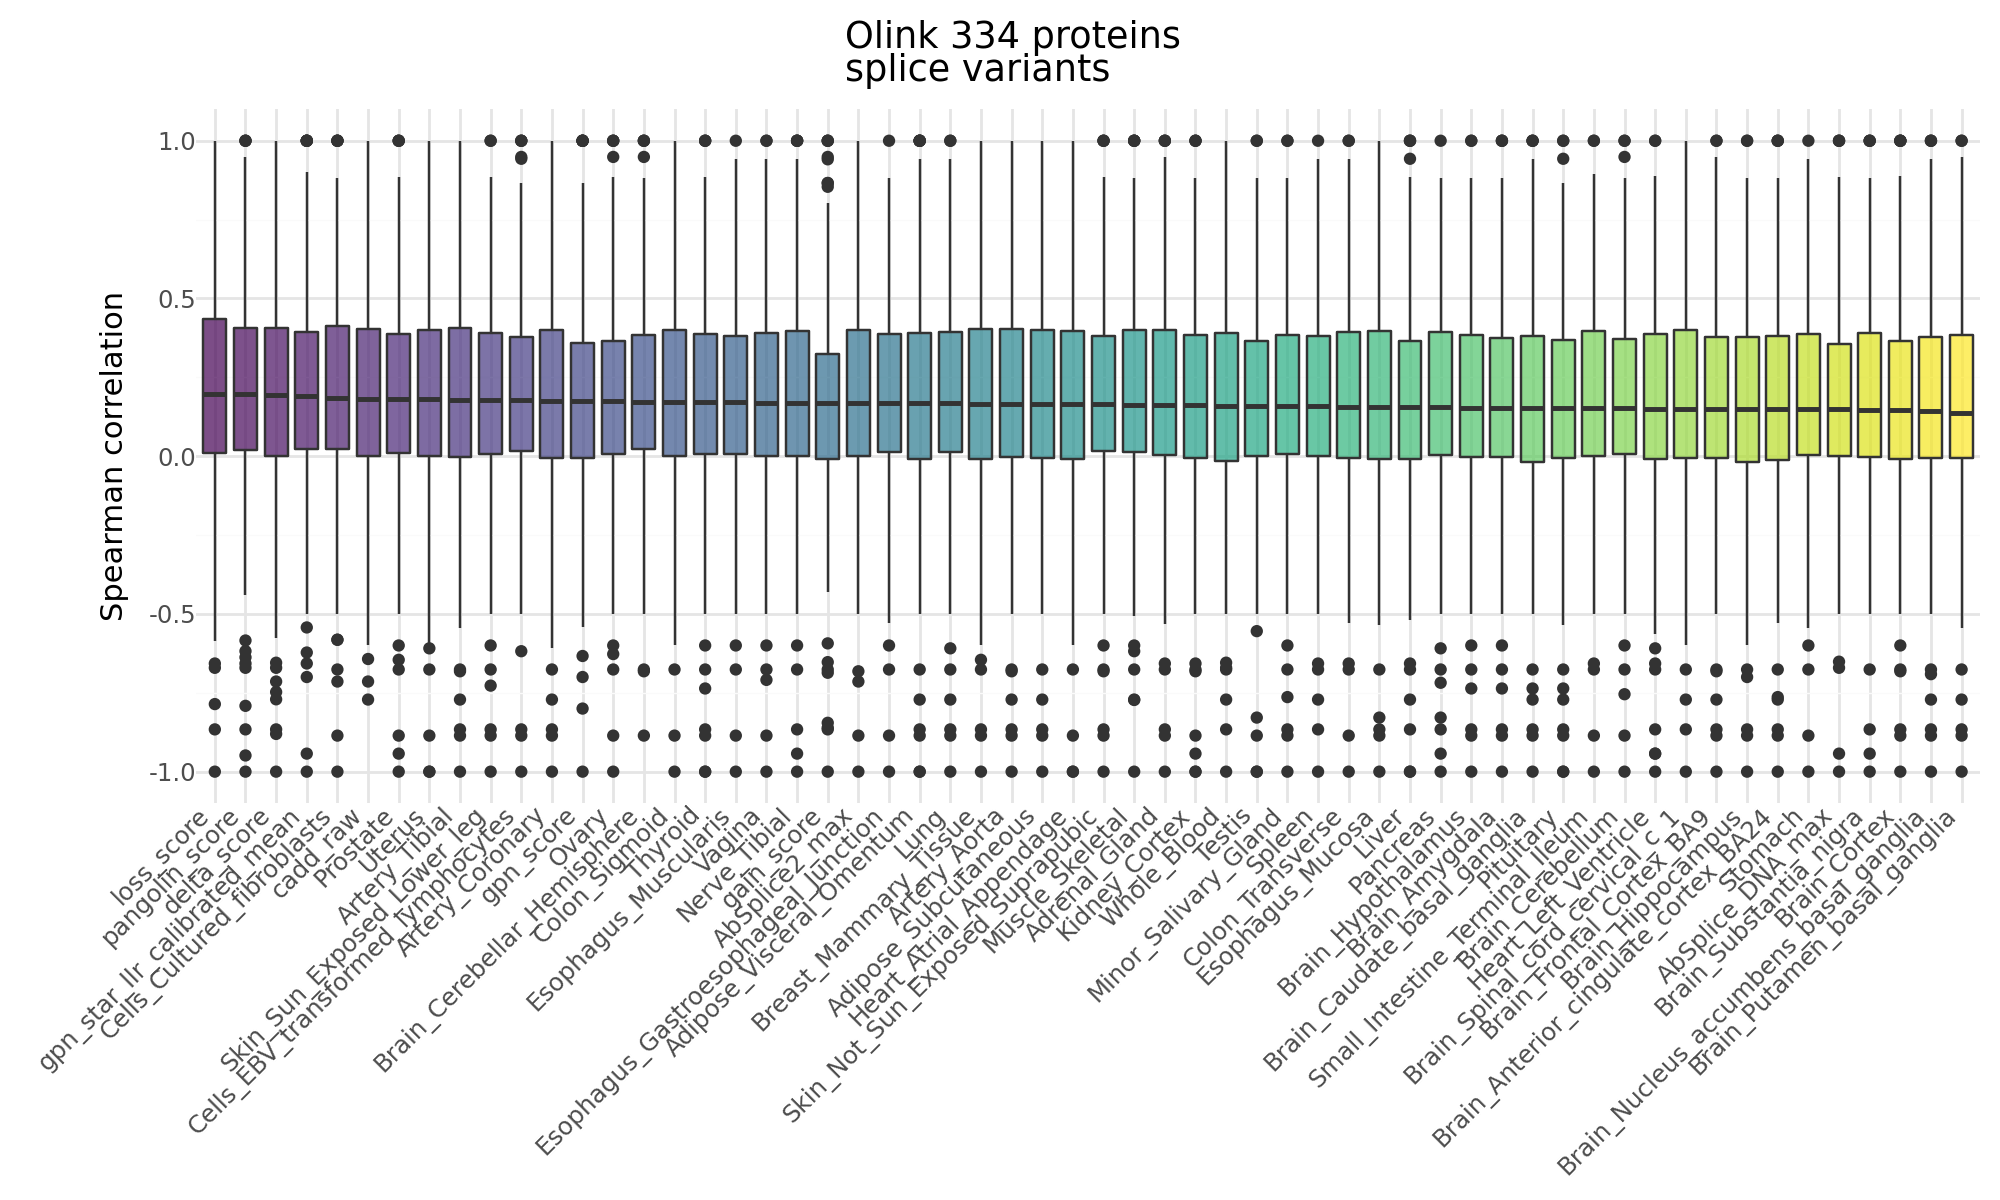

In [39]:
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['annotation'] = pd.Categorical(
    corr_pd['annotation'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['annotation'].unique(),
    ordered=True
)

# color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="annotation", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    # scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.25, 0.25)
    # ) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins \
            \nsplice variants"
            # \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(
        figure_size=(10, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1)
    )
)

In [40]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_772410/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""Cells_Cultured_fibroblasts""","""Brain_Caudate_basal_ganglia""",334,12550.0,0.000034
"""Cells_Cultured_fibroblasts""","""Brain_Cortex""",334,12786.0,0.000108
"""Cells_Cultured_fibroblasts""","""Brain_Putamen_basal_ganglia""",334,12996.0,0.000212
"""Brain_Hippocampus""","""Cells_Cultured_fibroblasts""",334,13706.0,0.000256
"""Cells_Cultured_fibroblasts""","""Brain_Frontal_Cortex_BA9""",334,13109.5,0.000302
…,…,…,…,…
"""Brain_Substantia_nigra""","""loss_score""",334,22272.0,0.04882
"""Uterus""","""Heart_Left_Ventricle""",334,13884.0,0.048878
"""Heart_Left_Ventricle""","""pangolin_score""",334,21842.0,0.048916
